In [1]:
import pandas as pd
import numpy as np

import time
import datetime as dt

from scipy.stats import norm


In [2]:
csv_options = pd.read_csv('icecleared_gasoptions_2026_03_17.csv', header=0, index_col=0)
csv_underlying = pd.read_csv("icecleared_gas_2026_03_17.csv", header=0, index_col = 0)

In [3]:
index = "JKM"
df1_underlying = csv_underlying[csv_underlying.CONTRACT == "JKM"]
df1_opt = csv_options[csv_options.CONTRACT == "JKM"]

In [4]:
df = pd.merge(df1_opt, df1_underlying[["SETTLEMENT PRICE", "EXPIRATION DATE"]], on ="EXPIRATION DATE", how="inner")

In [5]:
print(df1_opt.shape)
print(df.shape)

(600, 12)
(600, 13)


In [6]:
df

,HUB,PRODUCT,STRIP,CONTRACT,CONTRACT TYPE,STRIKE,SETTLEMENT PRICE_x,NET CHANGE,EXPIRATION DATE,PRODUCT_ID,OPTION_VOLATILITY,DELTA_FACTOR,SETTLEMENT PRICE_y
0,JKM,LNG Futures,5/1/2026,JKM,C,5.0,14.414,-0.119,4/15/2026,4172,103.7693,1.0,19.414
1,JKM,LNG Futures,5/1/2026,JKM,C,8.0,11.414,-0.119,4/15/2026,4172,68.3377,1.0,19.414
2,JKM,LNG Futures,5/1/2026,JKM,C,9.0,10.414,-0.119,4/15/2026,4172,59.4640,1.0,19.414
3,JKM,LNG Futures,5/1/2026,JKM,C,10.0,9.414,-0.119,4/15/2026,4172,51.5178,1.0,19.414
4,JKM,LNG Futures,5/1/2026,JKM,C,11.5,7.914,-0.119,4/15/2026,4172,40.9523,1.0,19.414
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,JKM,LNG Futures,6/1/2033,JKM,F,NaN,9.176,0.193,5/13/2033,4172,NaN,NaN,9.176
596,JKM,LNG Futures,7/1/2033,JKM,F,NaN,9.084,0.193,6/15/2033,4172,NaN,NaN,9.084
597,JKM,LNG Futures,8/1/2033,JKM,F,NaN,9.256,0.194,7/15/2033,4172,NaN,NaN,9.256
598,JKM,LNG Futures,9/1/2033,JKM,F,NaN,9.407,0.194,8/15/2033,4172,NaN,NaN,9.407


In [7]:
today = dt.date.today()
today

datetime.date(2026, 3, 24)

In [8]:
df["EXPIRATION DATE"] = pd.to_datetime(df["EXPIRATION DATE"], format="%m/%d/%Y").dt.date
df["EXPIRATION DATE"]

0      2026-04-15
1      2026-04-15
2      2026-04-15
3      2026-04-15
4      2026-04-15
          ...    
595    2033-05-13
596    2033-06-15
597    2033-07-15
598    2033-08-15
599    2033-09-15
Name: EXPIRATION DATE, Length: 600, dtype: object

In [9]:
df["TIME TO MATURITY"] = (df["EXPIRATION DATE"] - today).dt.days
df["TIME TO MATURITY-365"] = df["TIME TO MATURITY"]/365

In [10]:
df

,HUB,PRODUCT,STRIP,CONTRACT,CONTRACT TYPE,STRIKE,SETTLEMENT PRICE_x,NET CHANGE,EXPIRATION DATE,PRODUCT_ID,OPTION_VOLATILITY,DELTA_FACTOR,SETTLEMENT PRICE_y,TIME TO MATURITY,TIME TO MATURITY-365
0,JKM,LNG Futures,5/1/2026,JKM,C,5.0,14.414,-0.119,2026-04-15,4172,103.7693,1.0,19.414,22,0.060274
1,JKM,LNG Futures,5/1/2026,JKM,C,8.0,11.414,-0.119,2026-04-15,4172,68.3377,1.0,19.414,22,0.060274
2,JKM,LNG Futures,5/1/2026,JKM,C,9.0,10.414,-0.119,2026-04-15,4172,59.4640,1.0,19.414,22,0.060274
3,JKM,LNG Futures,5/1/2026,JKM,C,10.0,9.414,-0.119,2026-04-15,4172,51.5178,1.0,19.414,22,0.060274
4,JKM,LNG Futures,5/1/2026,JKM,C,11.5,7.914,-0.119,2026-04-15,4172,40.9523,1.0,19.414,22,0.060274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,JKM,LNG Futures,6/1/2033,JKM,F,NaN,9.176,0.193,2033-05-13,4172,NaN,NaN,9.176,2607,7.142466
596,JKM,LNG Futures,7/1/2033,JKM,F,NaN,9.084,0.193,2033-06-15,4172,NaN,NaN,9.084,2640,7.232877
597,JKM,LNG Futures,8/1/2033,JKM,F,NaN,9.256,0.194,2033-07-15,4172,NaN,NaN,9.256,2670,7.315068
598,JKM,LNG Futures,9/1/2033,JKM,F,NaN,9.407,0.194,2033-08-15,4172,NaN,NaN,9.407,2701,7.400000


In [11]:
def BS_d1(S, K, r, sigma, t):
    d1 = (np.log(S/K) + (r+sigma*sigma*0.5)*t) / (sigma*(np.sqrt(t)))
    return d1

def BS_d2(d1, sigma, t):
    d2 = d1 - sigma*np.sqrt(t)
    return d2

def Black76_d1(F, K, sigma, t):
    d1 = (np.log(F/K) + (sigma*sigma*0.5)*t) / (sigma*(np.sqrt(t)))
    return d1

def Black76_d2(d1, sigma, t):
    d2 = d1 - sigma*np.sqrt(t)
    return d2

## SOFR Rates

####  Create Calendar based on 1m SOFR (ffill only)

5. Interpolating for interest rates (1m SOFR)


In [12]:
sofr_1m = pd.read_excel("sofr.xlsx", sheet_name="daily-1m", header=0, index_col=0)
sofr_3m = pd.read_excel("sofr.xlsx", sheet_name="daily-3m", header=0, index_col=0)

In [13]:
df

,HUB,PRODUCT,STRIP,CONTRACT,CONTRACT TYPE,STRIKE,SETTLEMENT PRICE_x,NET CHANGE,EXPIRATION DATE,PRODUCT_ID,OPTION_VOLATILITY,DELTA_FACTOR,SETTLEMENT PRICE_y,TIME TO MATURITY,TIME TO MATURITY-365
0,JKM,LNG Futures,5/1/2026,JKM,C,5.0,14.414,-0.119,2026-04-15,4172,103.7693,1.0,19.414,22,0.060274
1,JKM,LNG Futures,5/1/2026,JKM,C,8.0,11.414,-0.119,2026-04-15,4172,68.3377,1.0,19.414,22,0.060274
2,JKM,LNG Futures,5/1/2026,JKM,C,9.0,10.414,-0.119,2026-04-15,4172,59.4640,1.0,19.414,22,0.060274
3,JKM,LNG Futures,5/1/2026,JKM,C,10.0,9.414,-0.119,2026-04-15,4172,51.5178,1.0,19.414,22,0.060274
4,JKM,LNG Futures,5/1/2026,JKM,C,11.5,7.914,-0.119,2026-04-15,4172,40.9523,1.0,19.414,22,0.060274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,JKM,LNG Futures,6/1/2033,JKM,F,NaN,9.176,0.193,2033-05-13,4172,NaN,NaN,9.176,2607,7.142466
596,JKM,LNG Futures,7/1/2033,JKM,F,NaN,9.084,0.193,2033-06-15,4172,NaN,NaN,9.084,2640,7.232877
597,JKM,LNG Futures,8/1/2033,JKM,F,NaN,9.256,0.194,2033-07-15,4172,NaN,NaN,9.256,2670,7.315068
598,JKM,LNG Futures,9/1/2033,JKM,F,NaN,9.407,0.194,2033-08-15,4172,NaN,NaN,9.407,2701,7.400000


In [14]:
sofr_1m.T

,sofr_1m
2026-03-01,3.6625
2026-04-01,3.6700
2026-05-01,3.6700
2026-06-01,3.6650
2026-07-01,3.6500
2026-08-01,3.6200
2026-09-01,3.6050
2026-10-01,3.5850
2026-11-01,3.5650
2026-12-01,3.5400


- 3R is the annualized, implied compounded overnight interest rate over the reference period.
- Each SR3 has a three-month reference period and the rate R for each future represents the swap rate for that reference period

In [15]:
sofr_3m.T

contract_month,start_date,end_date,sofr_3m
2026-03-01,2026-03-17,2026-06-16,3.69
2026-06-01,2026-06-17,2026-09-15,3.625
2026-09-01,2026-09-16,2026-12-15,3.52
2026-12-01,2026-12-16,2026-03-16,3.345
2027-03-01,2026-03-17,2027-06-15,3.28
2027-06-01,2027-06-16,2027-07-14,3.36
2027-09-01,2027-07-15,2027-12-14,3.47
2027-12-01,2027-12-15,2028-03-14,3.605
2028-03-01,2028-03-15,2028-06-20,3.77
2028-06-01,2028-06-21,2028-09-19,3.935


In [16]:
# Start and End date of all Tenors
today = pd.Timestamp.today()

start_date = sofr_1m.columns.min()
end_date = sofr_1m.columns.max() + pd.offsets.MonthEnd(0)

# Create Calendar based on start and end date

dates = pd.date_range(start=start_date, end=end_date, freq='D')

sofr_1m_calendar = pd.DataFrame(index=dates)

# 

sofr_1m_calendar["days_to_expiry"] = (sofr_1m_calendar.index - today).days

sofr_1m_calendar = sofr_1m_calendar.join(sofr_1m.T)
sofr_1m_calendar.sofr_1m = sofr_1m_calendar.sofr_1m.ffill()

In [17]:
sofr_1m_calendar

,days_to_expiry,sofr_1m
2026-03-01,-24,3.6625
2026-03-02,-23,3.6625
2026-03-03,-22,3.6625
2026-03-04,-21,3.6625
2026-03-05,-20,3.6625
...,...,...
2028-03-27,733,3.0800
2028-03-28,734,3.0800
2028-03-29,735,3.0800
2028-03-30,736,3.0800


<Axes: >

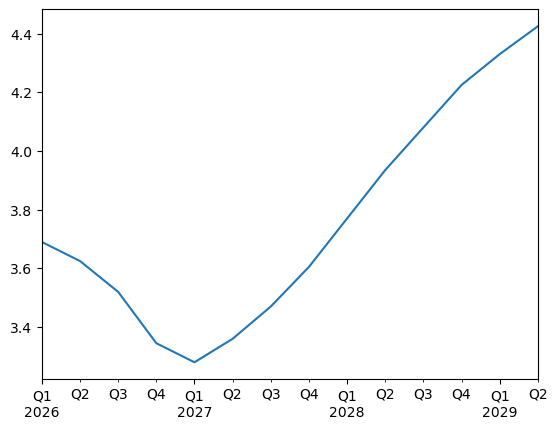

In [18]:
sofr_3m.T.sofr_3m.plot()

In [19]:
# because of limited 1m sofr rates, the options data becomes limited

df = df.merge(sofr_1m_calendar, left_on="TIME TO MATURITY", right_on="days_to_expiry", how="inner")

1. Calculate (Black Scholes, Black76 d1, d2)

In [20]:
F = df["SETTLEMENT PRICE_y"]
c_type = df["CONTRACT TYPE"]

K = df["STRIKE"]
r = df["sofr_1m"]
sigma = df["OPTION_VOLATILITY"]*0.01
t = df["TIME TO MATURITY-365"]

df["BS_d1"] = BS_d1(F, K, r, sigma, t)
df["BS_d2"] = BS_d2(df["BS_d1"], sigma, t)
df["Black76_d1"] = Black76_d1(F, K, sigma, t)
df["Black76_d2"] = Black76_d2(df["Black76_d1"], sigma, t)

In [21]:
df

,HUB,PRODUCT,STRIP,CONTRACT,CONTRACT TYPE,STRIKE,SETTLEMENT PRICE_x,NET CHANGE,EXPIRATION DATE,PRODUCT_ID,...,DELTA_FACTOR,SETTLEMENT PRICE_y,TIME TO MATURITY,TIME TO MATURITY-365,days_to_expiry,sofr_1m,BS_d1,BS_d2,Black76_d1,Black76_d2
0,JKM,LNG Futures,5/1/2026,JKM,C,5.0,14.414,-0.119,2026-04-15,4172,...,1.00000,19.414,22,0.060274,22,3.67,6.320475,6.065714,5.452191,5.197429
1,JKM,LNG Futures,5/1/2026,JKM,C,8.0,11.414,-0.119,2026-04-15,4172,...,1.00000,19.414,22,0.060274,22,3.67,6.686560,6.518786,5.368089,5.200315
2,JKM,LNG Futures,5/1/2026,JKM,C,9.0,10.414,-0.119,2026-04-15,4172,...,1.00000,19.414,22,0.060274,22,3.67,6.854176,6.708187,5.338952,5.192963
3,JKM,LNG Futures,5/1/2026,JKM,C,10.0,9.414,-0.119,2026-04-15,4172,...,1.00000,19.414,22,0.060274,22,3.67,7.057343,6.930863,5.308408,5.181928
4,JKM,LNG Futures,5/1/2026,JKM,C,11.5,7.914,-0.119,2026-04-15,4172,...,1.00000,19.414,22,0.060274,22,3.67,7.458720,7.358179,5.258568,5.158027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,JKM,LNG Futures,4/1/2028,JKM,P,7.0,0.515,NaN,2028-03-15,4172,...,-0.18910,9.314,722,1.978082,722,3.08,15.183985,14.757954,0.883409,0.457378
414,JKM,LNG Futures,4/1/2028,JKM,P,8.0,0.896,-0.252,2028-03-15,4172,...,-0.28443,9.314,722,1.978082,722,3.08,14.915088,14.490366,0.570424,0.145702
415,JKM,LNG Futures,4/1/2028,JKM,P,10.0,1.991,-0.306,2028-03-15,4172,...,-0.48189,9.314,722,1.978082,722,3.08,14.443600,14.020511,0.043574,-0.379515
416,JKM,LNG Futures,4/1/2028,JKM,P,13.0,4.255,-0.297,2028-03-15,4172,...,-0.71674,9.314,722,1.978082,722,3.08,13.842890,13.420413,-0.577989,-1.000466


### [Matrix] Call/Put Price - Time to Maturity x Strike

In [22]:
df[df["CONTRACT TYPE"] == "C"].pivot_table(index='STRIKE',columns='TIME TO MATURITY', values='SETTLEMENT PRICE_x').reset_index()

TIME TO MATURITY,STRIKE,22,52,83,113,143,175,205,234,266,...,448,478,507,540,570,601,631,661,693,722
0,5.0,14.414,13.861,13.509,13.094,12.811,12.287,12.235,12.398,12.307,...,7.573,7.749,7.529,7.329,7.440,7.778,7.468,7.483,6.992,4.411
1,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.341,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.405,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.829
3,8.0,11.414,10.861,10.528,10.161,9.948,NaN,NaN,9.553,9.510,...,NaN,NaN,NaN,NaN,NaN,NaN,4.849,4.886,4.474,2.210
4,8.5,NaN,10.361,10.040,NaN,NaN,8.897,8.900,NaN,9.080,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9.0,10.414,9.861,9.558,9.231,9.063,8.443,8.459,8.680,8.663,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.5,NaN,NaN,9.081,NaN,NaN,7.999,8.031,8.263,8.259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,9.7,NaN,NaN,NaN,NaN,8.472,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9.8,NaN,NaN,NaN,NaN,8.390,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10.0,9.414,8.861,8.613,8.342,8.226,7.568,7.616,7.859,7.869,...,3.817,4.011,3.898,3.267,3.390,3.689,3.484,3.536,3.202,1.305


In [23]:
df[df["CONTRACT TYPE"] == "P"].pivot_table(index='STRIKE',columns='TIME TO MATURITY', values='SETTLEMENT PRICE_x').reset_index()

TIME TO MATURITY,STRIKE,22,52,83,113,143,175,205,234,266,...,448,478,507,540,570,601,631,661,693,722
0,5.0,0.001,0.001,0.001,0.002,0.009,0.003,0.006,0.011,0.019,...,0.075,0.084,0.105,0.024,0.026,0.026,0.035,0.040,0.056,0.097
1,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.053,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.515
3,8.0,0.001,0.001,0.019,0.069,0.146,NaN,NaN,0.166,0.222,...,NaN,NaN,NaN,NaN,NaN,NaN,0.416,0.443,0.538,0.896
4,8.5,NaN,0.001,0.031,NaN,NaN,0.113,0.171,NaN,0.292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9.0,0.001,0.001,0.049,0.139,0.261,0.159,0.230,0.293,0.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.5,NaN,NaN,0.072,NaN,NaN,0.215,0.302,0.376,0.471,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,9.7,NaN,NaN,NaN,NaN,0.370,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9.8,NaN,NaN,NaN,NaN,0.388,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10.0,0.001,0.001,0.104,0.250,0.424,0.284,0.387,0.472,0.581,...,1.319,1.346,1.474,0.962,0.976,0.937,1.051,1.093,1.266,1.991


### [Matrix] Call/Put Volatility [ICE] - Time to Maturity x Strike

In [24]:
df[df["CONTRACT TYPE"] == "C"].pivot_table(index='STRIKE',columns='TIME TO MATURITY', values='OPTION_VOLATILITY').reset_index()

TIME TO MATURITY,STRIKE,22,52,83,113,143,175,205,234,266,...,448,478,507,540,570,601,631,661,693,722
0,5.0,103.7693,71.3062,75.2076,77.6164,79.2320,61.6139,62.2649,62.7725,62.8751,...,48.2127,48.1820,48.2844,35.5405,35.4322,35.2992,35.2716,35.3204,35.3202,30.5259
1,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.9248,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.9745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.2914
3,8.0,68.3377,46.4409,75.2132,77.6221,79.2379,NaN,NaN,62.9212,63.0242,...,NaN,NaN,NaN,NaN,NaN,NaN,35.0704,35.1196,35.0973,30.1983
4,8.5,NaN,43.2351,75.2141,NaN,NaN,61.7857,62.4377,NaN,63.0490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9.0,59.4640,43.0674,75.2147,77.6242,79.2401,61.8103,62.4624,62.9708,63.0739,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.5,NaN,NaN,75.2159,NaN,NaN,61.8348,62.4872,62.9956,63.0987,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,9.7,NaN,NaN,NaN,NaN,79.2415,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9.8,NaN,NaN,NaN,NaN,79.2417,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10.0,51.5178,43.0561,75.2166,77.6261,79.2420,61.8594,62.5118,63.0203,63.1236,...,47.8838,47.8619,47.9522,35.2033,35.1032,34.9888,34.9483,34.9966,34.9671,30.0822


### [Matrix] Call/Put Delta Factor[ICE] - Time to Maturity x Strike

In [25]:
df[df["CONTRACT TYPE"] == "C"].pivot_table(index='STRIKE',columns='TIME TO MATURITY', values='DELTA_FACTOR').reset_index()

TIME TO MATURITY,STRIKE,22,52,83,113,143,175,205,234,266,...,448,478,507,540,570,601,631,661,693,722
0,5.0,1.00000,1.00000,0.99989,0.99907,0.99706,0.99892,0.99778,0.99652,0.99467,...,0.97564,0.97448,0.96960,0.98891,0.98822,0.98878,0.98561,0.98410,0.97849,0.95131
1,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.98668,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.97334,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.81090
3,8.0,1.00000,1.00000,0.99251,0.98011,0.96627,NaN,NaN,0.96196,0.95413,...,NaN,NaN,NaN,NaN,NaN,NaN,0.88155,0.87845,0.85684,0.71557
4,8.5,NaN,1.00000,0.98841,NaN,NaN,0.96747,0.95753,NaN,0.94233,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9.0,1.00000,0.99999,0.98288,0.96338,0.94484,0.95667,0.94544,0.93856,0.92915,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.5,NaN,NaN,0.97572,NaN,NaN,0.94397,0.93165,0.92460,0.91466,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,9.7,NaN,NaN,NaN,NaN,0.92637,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9.8,NaN,NaN,NaN,NaN,0.92351,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10.0,1.00000,0.99991,0.96676,0.93998,0.91763,0.92937,0.91622,0.90926,0.89897,...,0.75314,0.75931,0.74728,0.75703,0.76134,0.77761,0.75877,0.75753,0.72827,0.51811


In [26]:
df[df["CONTRACT TYPE"] == "P"].pivot_table(index='STRIKE',columns='TIME TO MATURITY', values='DELTA_FACTOR').reset_index()

TIME TO MATURITY,STRIKE,22,52,83,113,143,175,205,234,266,...,448,478,507,540,570,601,631,661,693,722
0,5.0,0.00000,0.00000,-0.00011,-0.00093,-0.00294,-0.00108,-0.00223,-0.00348,-0.00534,...,-0.02436,-0.02552,-0.03040,-0.01109,-0.01179,-0.01122,-0.01439,-0.01590,-0.02151,-0.04869
1,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.01332,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.02666,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.18910
3,8.0,0.00000,0.00000,-0.00749,-0.01989,-0.03373,NaN,NaN,-0.03804,-0.04587,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.11845,-0.12155,-0.14316,-0.28443
4,8.5,NaN,0.00000,-0.01159,NaN,NaN,-0.03253,-0.04247,NaN,-0.05767,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9.0,0.00000,-0.00001,-0.01712,-0.03662,-0.05516,-0.04333,-0.05456,-0.06144,-0.07086,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.5,NaN,NaN,-0.02428,NaN,NaN,-0.05603,-0.06836,-0.07540,-0.08534,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,9.7,NaN,NaN,NaN,NaN,-0.07363,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9.8,NaN,NaN,NaN,NaN,-0.07649,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10.0,0.00000,-0.00009,-0.03324,-0.06002,-0.08237,-0.07063,-0.08378,-0.09074,-0.10103,...,-0.24686,-0.24069,-0.25272,-0.24297,-0.23866,-0.22240,-0.24124,-0.24247,-0.27173,-0.48189


In [27]:
df[df["CONTRACT TYPE"] == "P"].pivot_table(index='STRIKE',columns='TIME TO MATURITY', values='OPTION_VOLATILITY').reset_index()

TIME TO MATURITY,STRIKE,22,52,83,113,143,175,205,234,266,...,448,478,507,540,570,601,631,661,693,722
0,5.0,103.7693,71.3062,75.2076,77.6164,79.2320,61.6139,62.2649,62.7725,62.8751,...,48.2127,48.1820,48.2844,35.5405,35.4322,35.2992,35.2716,35.3204,35.3202,30.5259
1,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.9248,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.9745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.2914
3,8.0,68.3377,46.4409,75.2132,77.6221,79.2379,NaN,NaN,62.9212,63.0242,...,NaN,NaN,NaN,NaN,NaN,NaN,35.0704,35.1196,35.0973,30.1983
4,8.5,NaN,43.2351,75.2141,NaN,NaN,61.7857,62.4377,NaN,63.0490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9.0,59.4640,43.0674,75.2147,77.6242,79.2401,61.8103,62.4624,62.9708,63.0739,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.5,NaN,NaN,75.2159,NaN,NaN,61.8348,62.4872,62.9956,63.0987,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,9.7,NaN,NaN,NaN,NaN,79.2415,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9.8,NaN,NaN,NaN,NaN,79.2417,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10.0,51.5178,43.0561,75.2166,77.6261,79.2420,61.8594,62.5118,63.0203,63.1236,...,47.8838,47.8619,47.9522,35.2033,35.1032,34.9888,34.9483,34.9966,34.9671,30.0822


2. Calculate Delta, Gamma, Vega, Rho (Based on Option Volatility Given (ICE))

In [28]:
def Black76_delta(c_type, F, K, r, sigma, t, d1):
    
    delta = np.where(
        c_type == 'C',
        np.exp(-r * t) * norm.cdf(d1),       
        -np.exp(-r * t) * norm.cdf(-d1)
    )
    
    return delta

def Black76_gamma(F, K, r, sigma, t, d1):
    gamma = np.exp(-r*t) * norm.pdf(d1, loc=0, scale=1) / F * sigma * np.sqrt(t)
    return gamma

def Black76_vega(S, K, r, sigma, t,d1):
    gamma = F * np.exp(-r*t) *  norm.pdf(d1, loc=0, scale=1) * np.sqrt(t)
    return gamma

# def Black76_rho(S, K, r, sigma, t):
#     gamma = F * np.exp(-r*t) *  norm.pdf(d1, loc=0, scale=1) * np.sqrt(t)
#     return gamma

In [29]:
df["Black76_delta"] = Black76_delta(c_type, F, K, r, sigma, t, df["Black76_d1"])

In [30]:
df["Black76_gamma"] = Black76_gamma(F, K, r, sigma, t, df["Black76_d1"])

In [31]:
df["Black76_vega"] = Black76_vega(F, K, r, sigma, t, df["Black76_d1"])

In [32]:
df

,HUB,PRODUCT,STRIP,CONTRACT,CONTRACT TYPE,STRIKE,SETTLEMENT PRICE_x,NET CHANGE,EXPIRATION DATE,PRODUCT_ID,...,TIME TO MATURITY-365,days_to_expiry,sofr_1m,BS_d1,BS_d2,Black76_d1,Black76_d2,Black76_delta,Black76_gamma,Black76_vega
0,JKM,LNG Futures,5/1/2026,JKM,C,5.0,14.414,-0.119,2026-04-15,4172,...,0.060274,22,3.67,6.320475,6.065714,5.452191,5.197429,0.801552,1.471833e-09,5.345886e-07
1,JKM,LNG Futures,5/1/2026,JKM,C,8.0,11.414,-0.119,2026-04-15,4172,...,0.060274,22,3.67,6.686560,6.518786,5.368089,5.200315,0.801552,1.527759e-09,8.426060e-07
2,JKM,LNG Futures,5/1/2026,JKM,C,9.0,10.414,-0.119,2026-04-15,4172,...,0.060274,22,3.67,6.854176,6.708187,5.338952,5.192963,0.801552,1.553793e-09,9.848475e-07
3,JKM,LNG Futures,5/1/2026,JKM,C,10.0,9.414,-0.119,2026-04-15,4172,...,0.060274,22,3.67,7.057343,6.930863,5.308408,5.181928,0.801552,1.583853e-09,1.158744e-06
4,JKM,LNG Futures,5/1/2026,JKM,C,11.5,7.914,-0.119,2026-04-15,4172,...,0.060274,22,3.67,7.458720,7.358179,5.258568,5.158027,0.801552,1.638318e-09,1.507822e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,JKM,LNG Futures,4/1/2028,JKM,P,7.0,0.515,NaN,2028-03-15,4172,...,1.978082,722,3.08,15.183985,14.757954,0.883409,0.457378,-0.000426,2.791355e-05,7.994074e-03
414,JKM,LNG Futures,4/1/2028,JKM,P,8.0,0.896,-0.252,2028-03-15,4172,...,1.978082,722,3.08,14.915088,14.490366,0.570424,0.145702,-0.000642,3.493705e-05,1.003636e-02
415,JKM,LNG Futures,4/1/2028,JKM,P,10.0,1.991,-0.306,2028-03-15,4172,...,1.978082,722,3.08,14.443600,14.020511,0.043574,-0.379515,-0.001091,4.091261e-05,1.179832e-02
416,JKM,LNG Futures,4/1/2028,JKM,P,13.0,4.255,-0.297,2028-03-15,4172,...,1.978082,722,3.08,13.842890,13.420413,-0.577989,-1.000466,-0.001623,3.460177e-05,9.992856e-03


In [33]:
df[df["CONTRACT TYPE"] == "C"].pivot_table(index='STRIKE',columns='TIME TO MATURITY', values='sofr_1m').reset_index()

TIME TO MATURITY,STRIKE,22,52,83,113,143,175,205,234,266,...,448,478,507,540,570,601,631,661,693,722
0,5.0,3.67,3.67,3.665,3.65,3.62,3.605,3.585,3.565,3.54,...,3.47,3.45,3.44,3.435,3.41,3.41,3.18,3.085,3.095,3.08
1,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.08
3,8.0,3.67,3.67,3.665,3.65,3.62,NaN,NaN,3.565,3.54,...,NaN,NaN,NaN,NaN,NaN,NaN,3.18,3.085,3.095,3.08
4,8.5,NaN,3.67,3.665,NaN,NaN,3.605,3.585,NaN,3.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9.0,3.67,3.67,3.665,3.65,3.62,3.605,3.585,3.565,3.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.5,NaN,NaN,3.665,NaN,NaN,3.605,3.585,3.565,3.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,9.7,NaN,NaN,NaN,NaN,3.62,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9.8,NaN,NaN,NaN,NaN,3.62,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10.0,3.67,3.67,3.665,3.65,3.62,3.605,3.585,3.565,3.54,...,3.47,3.45,3.44,3.435,3.41,3.41,3.18,3.085,3.095,3.08


In [34]:
df[df["CONTRACT TYPE"] == "C"].pivot_table(index='STRIKE',columns='TIME TO MATURITY', values='Black76_delta').reset_index()

TIME TO MATURITY,STRIKE,22,52,83,113,143,175,205,234,266,...,448,478,507,540,570,601,631,661,693,722
0,5.0,0.801552,0.592829,0.434536,0.322806,0.241536,0.177404,0.133260,0.101401,0.075412,...,0.013800,0.010638,0.008160,0.006141,0.004812,0.003604,0.004040,0.003689,0.002746,0.002151
1,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.074832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.073850,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001834
3,8.0,0.801552,0.592829,0.432000,0.317338,0.234537,NaN,NaN,0.098009,0.072418,...,NaN,NaN,NaN,NaN,NaN,NaN,0.003615,0.003294,0.002406,0.001618
4,8.5,NaN,0.592829,0.430474,NaN,NaN,0.172140,0.128102,NaN,0.071533,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9.0,0.801552,0.592828,0.428361,0.312234,0.229481,0.170276,0.126514,0.095660,0.070540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.5,NaN,NaN,0.425555,NaN,NaN,0.168066,0.124693,0.094250,0.069446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,9.7,NaN,NaN,NaN,NaN,0.225071,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9.8,NaN,NaN,NaN,NaN,0.224385,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10.0,0.801552,0.592809,0.421966,0.304921,0.222971,0.165509,0.122648,0.092695,0.068258,...,0.010651,0.008288,0.006287,0.004703,0.003708,0.002835,0.003110,0.002840,0.002044,0.001169


- With a fixed interest rate, the Delta of Call option that are heavily ITM does not go to 1

3a.Invert the Market Prices to obtain Implied Volatility for prices that are known

3b. using interest rates to back out Implied Vol (Not full spectrum of Implied Vol)

- Brent's Method (Implied Vol)

In [35]:
df

,HUB,PRODUCT,STRIP,CONTRACT,CONTRACT TYPE,STRIKE,SETTLEMENT PRICE_x,NET CHANGE,EXPIRATION DATE,PRODUCT_ID,...,TIME TO MATURITY-365,days_to_expiry,sofr_1m,BS_d1,BS_d2,Black76_d1,Black76_d2,Black76_delta,Black76_gamma,Black76_vega
0,JKM,LNG Futures,5/1/2026,JKM,C,5.0,14.414,-0.119,2026-04-15,4172,...,0.060274,22,3.67,6.320475,6.065714,5.452191,5.197429,0.801552,1.471833e-09,5.345886e-07
1,JKM,LNG Futures,5/1/2026,JKM,C,8.0,11.414,-0.119,2026-04-15,4172,...,0.060274,22,3.67,6.686560,6.518786,5.368089,5.200315,0.801552,1.527759e-09,8.426060e-07
2,JKM,LNG Futures,5/1/2026,JKM,C,9.0,10.414,-0.119,2026-04-15,4172,...,0.060274,22,3.67,6.854176,6.708187,5.338952,5.192963,0.801552,1.553793e-09,9.848475e-07
3,JKM,LNG Futures,5/1/2026,JKM,C,10.0,9.414,-0.119,2026-04-15,4172,...,0.060274,22,3.67,7.057343,6.930863,5.308408,5.181928,0.801552,1.583853e-09,1.158744e-06
4,JKM,LNG Futures,5/1/2026,JKM,C,11.5,7.914,-0.119,2026-04-15,4172,...,0.060274,22,3.67,7.458720,7.358179,5.258568,5.158027,0.801552,1.638318e-09,1.507822e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,JKM,LNG Futures,4/1/2028,JKM,P,7.0,0.515,NaN,2028-03-15,4172,...,1.978082,722,3.08,15.183985,14.757954,0.883409,0.457378,-0.000426,2.791355e-05,7.994074e-03
414,JKM,LNG Futures,4/1/2028,JKM,P,8.0,0.896,-0.252,2028-03-15,4172,...,1.978082,722,3.08,14.915088,14.490366,0.570424,0.145702,-0.000642,3.493705e-05,1.003636e-02
415,JKM,LNG Futures,4/1/2028,JKM,P,10.0,1.991,-0.306,2028-03-15,4172,...,1.978082,722,3.08,14.443600,14.020511,0.043574,-0.379515,-0.001091,4.091261e-05,1.179832e-02
416,JKM,LNG Futures,4/1/2028,JKM,P,13.0,4.255,-0.297,2028-03-15,4172,...,1.978082,722,3.08,13.842890,13.420413,-0.577989,-1.000466,-0.001623,3.460177e-05,9.992856e-03


In [36]:
def black76Price(F, r, sigma, t, K, c_type):
    

    d1 = Black76_d1(F, K, sigma, t)
    d2 = Black76_d2(d1, sigma, t)
    
    call_price = np.exp(-r*t)*(F*norm.cdf(d1)-K*norm.cdf(d2))
    put_price = np.exp(-r*t)*(K*norm.cdf(-d2)-F*norm.cdf(-d1)) 
    
    if c_type == 'C':
        return call_price
    else:
        return put_price

    
def BSPrice(S, r, sigma, t, K, c_type):
    

    d1 = BS_d1(S, K, r, sigma, t)
    d2 = BS_d2(d1, sigma, t)
    
    call_price = S*norm.cdf(d1) - K*np.exp(-r*t)*norm.cdf(d2)
    put_price = K*np.exp(-r*t)*norm.cdf(-d2) - S*norm.cdf(-d1) 
    
    if c_type == 'C':
        return call_price
    else:
        return put_price

In [37]:
# Volatility Testing - Price increase with vol increase

S = 100
K = 100
r = 0.01
t = 0.5
c_type = 'C'

for sigma in [0.01, 0.1, 0.2, 0.5, 1.0, 2.0, 3.0]:
    print(sigma, BSPrice(S, r, sigma, t, K, c_type))

0.01 0.598323102227539
0.1 3.0697305092269715
0.2 5.876024233827607
0.5 14.247390137989271
1.0 27.81376672837888
2.0 52.16983755685243
3.0 71.18772783925178


#### Bisection Method - Implied Volatility

In [38]:
def bisect(row):
    return bisection_iv(
        row["SETTLEMENT PRICE_y"], 
        row["sofr_1m"]/100,  
        row["TIME TO MATURITY-365"],
        row["STRIKE"],
        row["CONTRACT TYPE"],
        row["SETTLEMENT PRICE_x"] #option price
    )

     
def bisection_iv(F, r, t, K, c_type, market_price, a=1e-8, b=10, tol=1e-3):
    
    def f(sigma):
        print("bsprice: ",BSPrice(F, r, sigma, t, K, c_type))
        print("mkt price: ",market_price)
        return BSPrice(F, r, sigma, t, K, c_type) - market_price

    if f(a) * f(b) >= 0:
        print("f(a)", f(a))
        print("f(b)", f(b))
        print("Invalid interval: f(a) and f(b) must have opposite signs.")
        return np.nan
    
    while (b - a) / 2 > tol:
        c = (a + b) / 2
    
        if f(b) == 0:
            return c
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c

    return (a + b) / 2
    
df["implied_vol"] = df.apply(bisect, axis=1)

bsprice:  14.42504805002158
mkt price:  14.414
bsprice:  17.438930521384677
mkt price:  14.414
bsprice:  14.42504805002158
mkt price:  14.414
f(a) 0.01104805002158038
bsprice:  17.438930521384677
mkt price:  14.414
f(b) 3.024930521384677
Invalid interval: f(a) and f(b) must have opposite signs.
bsprice:  11.431676880034527
mkt price:  11.414
bsprice:  16.783851834488498
mkt price:  11.414
bsprice:  11.431676880034527
mkt price:  11.414
f(a) 0.017676880034526832
bsprice:  16.783851834488498
mkt price:  11.414
f(b) 5.3698518344884985
Invalid interval: f(a) and f(b) must have opposite signs.
bsprice:  10.433886490038843
mkt price:  10.414
bsprice:  16.59750467036574
mkt price:  10.414
bsprice:  10.433886490038843
mkt price:  10.414
f(a) 0.019886490038842908
bsprice:  16.59750467036574
mkt price:  10.414
f(b) 6.183504670365741
Invalid interval: f(a) and f(b) must have opposite signs.
bsprice:  9.436096100043159
mkt price:  9.414
bsprice:  16.423065017018512
mkt price:  9.414
bsprice:  9.43

bsprice:  6.986968916975355
mkt price:  0.001
bsprice:  6.986968916975355
mkt price:  0.001
bsprice:  0.0
mkt price:  0.001
bsprice:  2.8692326112722437
mkt price:  0.001
bsprice:  2.8692326112722437
mkt price:  0.001
bsprice:  0.0
mkt price:  0.001
bsprice:  0.5861480057512574
mkt price:  0.001
bsprice:  0.5861480057512574
mkt price:  0.001
bsprice:  0.0
mkt price:  0.001
bsprice:  0.022576711745856293
mkt price:  0.001
bsprice:  0.022576711745856293
mkt price:  0.001
bsprice:  0.0
mkt price:  0.001
bsprice:  3.2287585362679536e-06
mkt price:  0.001
bsprice:  0.022576711745856293
mkt price:  0.001
bsprice:  3.2287585362679536e-06
mkt price:  0.001
bsprice:  0.0017738104155274673
mkt price:  0.001
bsprice:  0.0017738104155274673
mkt price:  0.001
bsprice:  3.2287585362679536e-06
mkt price:  0.001
bsprice:  0.000174877121517549
mkt price:  0.001
bsprice:  0.0017738104155274673
mkt price:  0.001
bsprice:  0.000174877121517549
mkt price:  0.001
bsprice:  0.000639429029255319
mkt price:  0

bsprice:  0.0001173174694134799
mkt price:  0.001
bsprice:  0.0005343322767360527
mkt price:  0.001
bsprice:  0.0016604939692068804
mkt price:  0.001
bsprice:  0.0005343322767360527
mkt price:  0.001
bsprice:  0.000978770514891071
mkt price:  0.001
bsprice:  0.0016604939692068804
mkt price:  0.001
bsprice:  0.000978770514891071
mkt price:  0.001
bsprice:  0.0012859436261290214
mkt price:  0.001
bsprice:  0.0012859436261290214
mkt price:  0.001
bsprice:  0.000978770514891071
mkt price:  0.001
bsprice:  0.0011244452484552858
mkt price:  0.001
bsprice:  0.0011244452484552858
mkt price:  0.001
bsprice:  0.000978770514891071
mkt price:  0.001
bsprice:  0.0010496932888958144
mkt price:  0.001
bsprice:  0.0010496932888958144
mkt price:  0.001
bsprice:  0.000978770514891071
mkt price:  0.001
bsprice:  0.001013761138518872
mkt price:  0.001
bsprice:  0.5418077999136841
mkt price:  1.017
bsprice:  15.63317009637421
mkt price:  1.017
bsprice:  15.63317009637421
mkt price:  1.017
bsprice:  0.54180

bsprice:  0.0010188958526031276
mkt price:  0.001
bsprice:  0.0009659993052912085
mkt price:  0.001
bsprice:  0.0009921701372788503
mkt price:  0.001
bsprice:  0.0010188958526031276
mkt price:  0.001
bsprice:  0.0009921701372788503
mkt price:  0.001
bsprice:  0.0010054631326500106
mkt price:  0.001
bsprice:  0.0
mkt price:  0.001
bsprice:  7.247524846858781
mkt price:  0.001
bsprice:  7.247524846858781
mkt price:  0.001
bsprice:  0.0
mkt price:  0.001
bsprice:  3.943815366397539
mkt price:  0.001
bsprice:  3.943815366397539
mkt price:  0.001
bsprice:  0.0
mkt price:  0.001
bsprice:  1.056039151525897
mkt price:  0.001
bsprice:  1.056039151525897
mkt price:  0.001
bsprice:  0.0
mkt price:  0.001
bsprice:  0.07508727702306844
mkt price:  0.001
bsprice:  0.07508727702306844
mkt price:  0.001
bsprice:  0.0
mkt price:  0.001
bsprice:  8.86721765261105e-05
mkt price:  0.001
bsprice:  0.07508727702306844
mkt price:  0.001
bsprice:  8.86721765261105e-05
mkt price:  0.001
bsprice:  0.0103599961

bsprice:  0.33261780900163496
mkt price:  0.125
bsprice:  0.017409632466142244
mkt price:  0.125
bsprice:  0.12800126126617406
mkt price:  0.125
bsprice:  0.12800126126617406
mkt price:  0.125
bsprice:  0.017409632466142244
mkt price:  0.125
bsprice:  0.05888539651719149
mkt price:  0.125
bsprice:  0.12800126126617406
mkt price:  0.125
bsprice:  0.05888539651719149
mkt price:  0.125
bsprice:  0.09017297807367464
mkt price:  0.125
bsprice:  0.12800126126617406
mkt price:  0.125
bsprice:  0.09017297807367464
mkt price:  0.125
bsprice:  0.10830477551198125
mkt price:  0.125
bsprice:  0.12800126126617406
mkt price:  0.125
bsprice:  0.10830477551198125
mkt price:  0.125
bsprice:  0.11796219026473564
mkt price:  0.125
bsprice:  0.12800126126617406
mkt price:  0.125
bsprice:  0.11796219026473564
mkt price:  0.125
bsprice:  0.12293462656314147
mkt price:  0.125
bsprice:  0.12800126126617406
mkt price:  0.125
bsprice:  0.12293462656314147
mkt price:  0.125
bsprice:  0.12545624568111058
mkt pric

...

bsprice:  0.0
mkt price:  1.051
bsprice:  9.465090048130156
mkt price:  1.051
bsprice:  9.465090048130156
mkt price:  1.051
bsprice:  0.0
mkt price:  1.051
bsprice:  9.454115982131881
mkt price:  1.051
bsprice:  9.454115982131881
mkt price:  1.051
bsprice:  0.0
mkt price:  1.051
bsprice:  8.379898125901542
mkt price:  1.051
bsprice:  8.379898125901542
mkt price:  1.051
bsprice:  0.0
mkt price:  1.051
bsprice:  5.032556960224762
mkt price:  1.051
bsprice:  5.032556960224762
mkt price:  1.051
bsprice:  0.0
mkt price:  1.051
bsprice:  2.185726063095304
mkt price:  1.051
bsprice:  2.185726063095304
mkt price:  1.051
bsprice:  0.0
mkt price:  1.051
bsprice:  0.6689319662938034
mkt price:  1.051
bsprice:  2.185726063095304
mkt price:  1.051
bsprice:  0.6689319662938034
mkt price:  1.051
bsprice:  1.4116255455711033
mkt price:  1.051
bsprice:  1.4116255455711033
mkt price:  1.051
bsprice:  0.6689319662938034
mkt price:  1.051
bsprice:  1.0318491389877553
mkt price:  1.051
bsprice:  1.41162554

bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  nan
mkt price:  12.443
bsprice:  0.0
mkt price:  0.04
bsprice:  4.7283193877110845
mkt price:  0.04
bsprice:  4.7283193877110845
mkt price:  0.04
bsprice:  0.0
mkt price:  0.04
bsprice:  4.722486088727213
mkt price:  0.04
bsprice:  4.722486088727213
mkt price:  0.04
bsprice:  0.0
mkt price:  0.04
bsprice:  4.038574514903443
mkt price:  0.04
bsprice:  4.038574514903443
mkt price:  0.04
bsprice:  0.0
mkt price:  0.04
bsprice:  1.8849592666152306
mkt price:  0.

bsprice:  2.6644044941938425
mkt price:  3.202
bsprice:  3.3350523116416966
mkt price:  3.202
bsprice:  2.6644044941938425
mkt price:  3.202
bsprice:  2.968400824789682
mkt price:  3.202
bsprice:  3.3350523116416966
mkt price:  3.202
bsprice:  2.968400824789682
mkt price:  3.202
bsprice:  3.146969686424736
mkt price:  3.202
bsprice:  3.3350523116416966
mkt price:  3.202
bsprice:  3.146969686424736
mkt price:  3.202
bsprice:  3.2400653672481434
mkt price:  3.202
bsprice:  3.2400653672481434
mkt price:  3.202
bsprice:  3.146969686424736
mkt price:  3.202
bsprice:  3.1932548836634878
mkt price:  3.202
bsprice:  3.2400653672481434
mkt price:  3.202
bsprice:  3.1932548836634878
mkt price:  3.202
bsprice:  3.21659796876454
mkt price:  3.202
bsprice:  3.21659796876454
mkt price:  3.202
bsprice:  3.1932548836634878
mkt price:  3.202
bsprice:  3.2049104641239206
mkt price:  3.202
bsprice:  3.2049104641239206
mkt price:  3.202
bsprice:  3.1932548836634878
mkt price:  3.202
bsprice:  3.1990786292

bsprice:  4.387707245394187
mkt price:  4.373
bsprice:  4.259592881397955
mkt price:  4.373
bsprice:  4.3236593578585225
mkt price:  4.373
bsprice:  4.387707245394187
mkt price:  4.373
bsprice:  4.3236593578585225
mkt price:  4.373
bsprice:  4.355686267171873
mkt price:  4.373
bsprice:  4.387707245394187
mkt price:  4.373
bsprice:  4.355686267171873
mkt price:  4.373
bsprice:  4.371697575671535
mkt price:  4.373
bsprice:  4.387707245394187
mkt price:  4.373
bsprice:  4.371697575671535
mkt price:  4.373
bsprice:  4.379702624995626
mkt price:  4.373
bsprice:  4.6095306569504615
mkt price:  4.411
bsprice:  9.31399999998656
mkt price:  4.411
bsprice:  4.6095306569504615
mkt price:  4.411
f(a) 0.1985306569504619
bsprice:  9.31399999998656
mkt price:  4.411
f(b) 4.9029999999865606
Invalid interval: f(a) and f(b) must have opposite signs.
bsprice:  2.7277429197306455
mkt price:  2.829
bsprice:  9.313999999984084
mkt price:  2.829
bsprice:  9.313999999984084
mkt price:  2.829
bsprice:  2.72774

bsprice:  1.528662064364179
mkt price:  0.515
bsprice:  1.528662064364179
mkt price:  0.515
bsprice:  0.0
mkt price:  0.515
bsprice:  0.4163532580404432
mkt price:  0.515
bsprice:  1.528662064364179
mkt price:  0.515
bsprice:  0.4163532580404432
mkt price:  0.515
bsprice:  0.9539957222693296
mkt price:  0.515
bsprice:  0.9539957222693296
mkt price:  0.515
bsprice:  0.4163532580404432
mkt price:  0.515
bsprice:  0.6761080442954326
mkt price:  0.515
bsprice:  0.6761080442954326
mkt price:  0.515
bsprice:  0.4163532580404432
mkt price:  0.515
bsprice:  0.5430890241194104
mkt price:  0.515
bsprice:  0.5430890241194104
mkt price:  0.515
bsprice:  0.4163532580404432
mkt price:  0.515
bsprice:  0.4787934040465718
mkt price:  0.515
bsprice:  0.5430890241194104
mkt price:  0.515
bsprice:  0.4787934040465718
mkt price:  0.515
bsprice:  0.5107289269262072
mkt price:  0.515
bsprice:  0.5430890241194104
mkt price:  0.515
bsprice:  0.5107289269262072
mkt price:  0.515
bsprice:  0.5268581831656187
mk

In [39]:
df.columns

Index(['HUB', 'PRODUCT', 'STRIP', 'CONTRACT', 'CONTRACT TYPE', 'STRIKE',
       'SETTLEMENT PRICE_x', 'NET CHANGE', 'EXPIRATION DATE', 'PRODUCT_ID',
       'OPTION_VOLATILITY', 'DELTA_FACTOR', 'SETTLEMENT PRICE_y',
       'TIME TO MATURITY', 'TIME TO MATURITY-365', 'days_to_expiry', 'sofr_1m',
       'BS_d1', 'BS_d2', 'Black76_d1', 'Black76_d2', 'Black76_delta',
       'Black76_gamma', 'Black76_vega', 'implied_vol'],
      dtype='object')

In [40]:
df[df["CONTRACT TYPE"] == "C"].pivot_table(index='STRIKE',columns='TIME TO MATURITY', values='implied_vol').reset_index()

TIME TO MATURITY,STRIKE,22,52,83,113,143,175,205,234,266,...,448,478,507,540,570,601,631,661,693,722
0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.193481
1,8.0,NaN,NaN,NaN,NaN,0.631714,NaN,NaN,NaN,0.418091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.162964,0.220337,0.232544
2,8.5,NaN,NaN,NaN,NaN,NaN,NaN,0.333862,NaN,0.487671,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9.0,NaN,NaN,NaN,0.637817,0.706177,0.372925,0.475464,0.501099,0.518188,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9.5,NaN,NaN,NaN,NaN,NaN,0.480347,0.514526,0.527954,0.538940,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9.7,NaN,NaN,NaN,NaN,0.729370,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.8,NaN,NaN,NaN,NaN,0.731812,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,10.0,NaN,NaN,0.604858,0.703735,0.736694,0.516968,0.536499,0.546265,0.552368,...,0.422974,0.421753,0.422974,0.278931,0.275269,0.266724,0.277710,0.280151,0.285034,0.259399
8,10.5,NaN,NaN,NaN,NaN,NaN,0.538940,0.552368,0.558472,0.563355,...,0.427856,0.425415,0.427856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,11.0,NaN,NaN,NaN,NaN,NaN,0.553589,0.563355,0.568237,0.570679,...,0.431519,0.430298,0.431519,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Raphson Newton Method - Implied Volatility

vega = first derivative wrt to volatility - measures change in volatility vs change in option price
- formula = S * np.sqrt(t) * N(d1)
- formula = dV/dsigma

raphson newton method 

x(n+1) = x(n) - f(xn)/f'(xn)

We can take f(xn)/f'(xn) as vega

x(n) - sigma at time n
x(n+1) - sigma at time (n+1)



In [41]:
df.columns

Index(['HUB', 'PRODUCT', 'STRIP', 'CONTRACT', 'CONTRACT TYPE', 'STRIKE',
       'SETTLEMENT PRICE_x', 'NET CHANGE', 'EXPIRATION DATE', 'PRODUCT_ID',
       'OPTION_VOLATILITY', 'DELTA_FACTOR', 'SETTLEMENT PRICE_y',
       'TIME TO MATURITY', 'TIME TO MATURITY-365', 'days_to_expiry', 'sofr_1m',
       'BS_d1', 'BS_d2', 'Black76_d1', 'Black76_d2', 'Black76_delta',
       'Black76_gamma', 'Black76_vega', 'implied_vol'],
      dtype='object')

In [45]:
def raphson_newton(row):
    return raphson_newton_iv(
        row["SETTLEMENT PRICE_y"], 
        row["sofr_1m"]/100,  
        row["TIME TO MATURITY-365"],
        row["STRIKE"],
        row["CONTRACT TYPE"],
        row["SETTLEMENT PRICE_x"] #option price
    )

# Calculates vega
def calculate_vega_optionPrice(S, r, sigma, t, K, c_type):
    
    d1 = BS_d1(S, K, r, sigma, t)

    vega = S * np.sqrt(t) * norm.pdf(d1)
    
    price = BSPrice(S, r, sigma, t, K, c_type) 
    
    return vega, price

    
# Set Paramters
def raphson_newton_iv(S, r, t, K, c_type, market_price, initial=0.1,  tol=1e-4, max_iter=1000):
    
    sigma = initial
    
    for i in range(max_iter):
        vega, price = calculate_vega_optionPrice(S, r, sigma, t, K, c_type)
        price_diff = price - market_price

        if abs(price_diff)<tol:
            return sigma
        
        else:
            sigma = sigma - price_diff/vega

        
# Driver program to test above
df["implied_vol_RN"] = df.apply(raphson_newton, axis=1)

C:\Users\yvonne.ang\AppData\Local\Temp\ipykernel_39460\4136481987.py:36: RuntimeWarning: divide by zero encountered in double_scalars
  sigma = sigma - price_diff/vega
C:\Users\yvonne.ang\AppData\Local\Temp\ipykernel_39460\1778842059.py:2: RuntimeWarning: invalid value encountered in double_scalars
  d1 = (np.log(S/K) + (r+sigma*sigma*0.5)*t) / (sigma*(np.sqrt(t)))
C:\Users\yvonne.ang\AppData\Local\Temp\ipykernel_39460\1778842059.py:2: RuntimeWarning: overflow encountered in double_scalars
  d1 = (np.log(S/K) + (r+sigma*sigma*0.5)*t) / (sigma*(np.sqrt(t)))


In [46]:
df[df["CONTRACT TYPE"] == "C"].pivot_table(index='STRIKE',columns='TIME TO MATURITY', values='implied_vol_RN').reset_index()

TIME TO MATURITY,STRIKE,22,52,83,113,143,175,205,234,266,...,448,478,507,540,570,601,631,661,693,722
0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.193102
1,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.233010
2,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.278513,0.275149,0.266459,0.277424,0.279722,0.285039,0.258807
3,10.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.428231,NaN,0.427765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.432114,0.429714,0.431223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.306970,0.307670,0.308961,0.272786
6,15.0,NaN,NaN,NaN,NaN,NaN,NaN,0.604677,0.606616,0.605679,...,0.448412,0.446452,0.446996,0.318783,0.316317,0.312345,0.314911,0.315454,0.316022,NaN
7,15.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.609032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,16.5,NaN,NaN,NaN,NaN,NaN,0.611473,0.614820,0.616753,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,17.0,NaN,NaN,NaN,0.775807,0.786417,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


4. Local Vol  